In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
#import torch
#import torch.nn as nn
#import torch.optim as optim

# Set random seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)


In [3]:
# Load datasets
classification_data = pd.read_csv(r"Data\Classification.csv")
#detect_data=pd.read_csv(r"Data\Fault Detect.csv")



In [4]:
classification_data.head()
#detect_data.head()


,Id,Iq,Vd,Vq,Wm,Output,Unnamed: 6,Unnamed: 7,Unnamed: 8
0,0.000000e+00,0.000000,0.000000,-339.000000,0.000000e+00,0,NaN,0.0,healthy
1,1.310000e-10,-0.000201,0.000442,-339.000000,-2.610000e-09,0,NaN,1.0,phase A fault
2,4.720000e-09,-0.001206,0.002651,-339.000000,-9.410000e-08,0,NaN,2.0,phase A & B fault
3,1.260000e-07,-0.006229,0.013699,-339.000000,-2.510000e-06,0,NaN,3.0,Short Circuit
4,3.190000e-06,-0.031344,0.068939,-338.999993,-6.360000e-05,0,NaN,4.0,Open Circuit


In [5]:
# Step 4: Data Preprocessing
class_df=classification_data.loc[:,~classification_data.columns.str.contains('^Unnamed')]
class_df.head()
#detect_df=detect_data.loc[:,~detect_data.columns.str.contains('^Unnamed')]
#detect_df.head()

,Id,Iq,Vd,Vq,Wm,Output
0,0.000000e+00,0.000000,0.000000,-339.000000,0.000000e+00,0
1,1.310000e-10,-0.000201,0.000442,-339.000000,-2.610000e-09,0
2,4.720000e-09,-0.001206,0.002651,-339.000000,-9.410000e-08,0
3,1.260000e-07,-0.006229,0.013699,-339.000000,-2.510000e-06,0
4,3.190000e-06,-0.031344,0.068939,-338.999993,-6.360000e-05,0


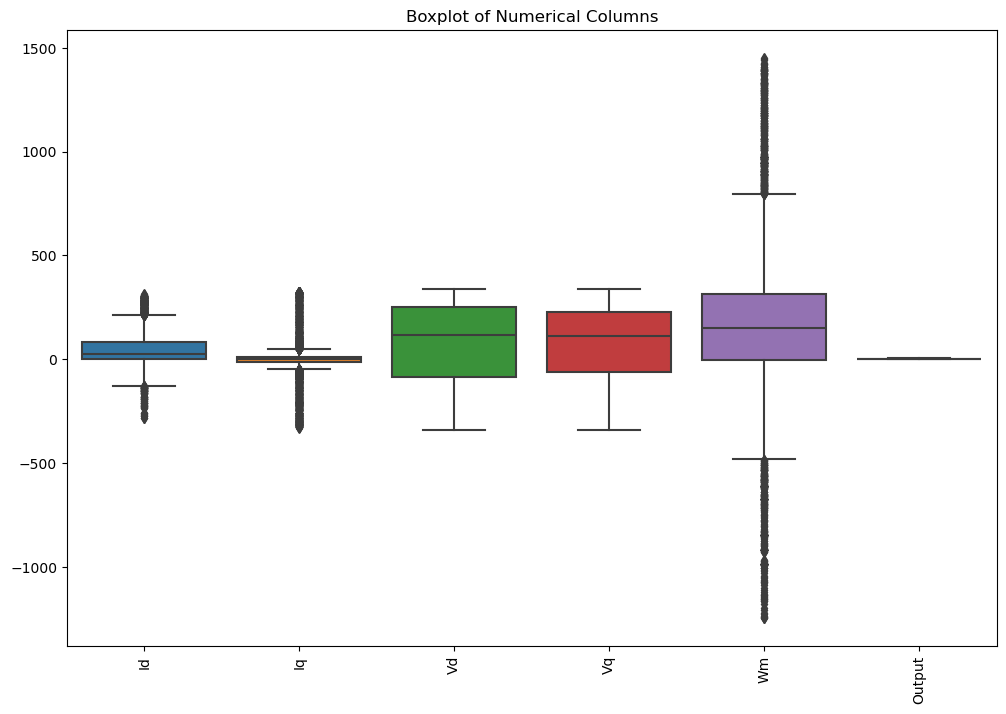

c:\Users\Derrick Baalaboore\.conda\envs\tf_env\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Derrick Baalaboore\.conda\envs\tf_env\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Derrick Baalaboore\.conda\envs\tf_env\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Derrick Baalaboore\.conda\envs\tf_env\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprec

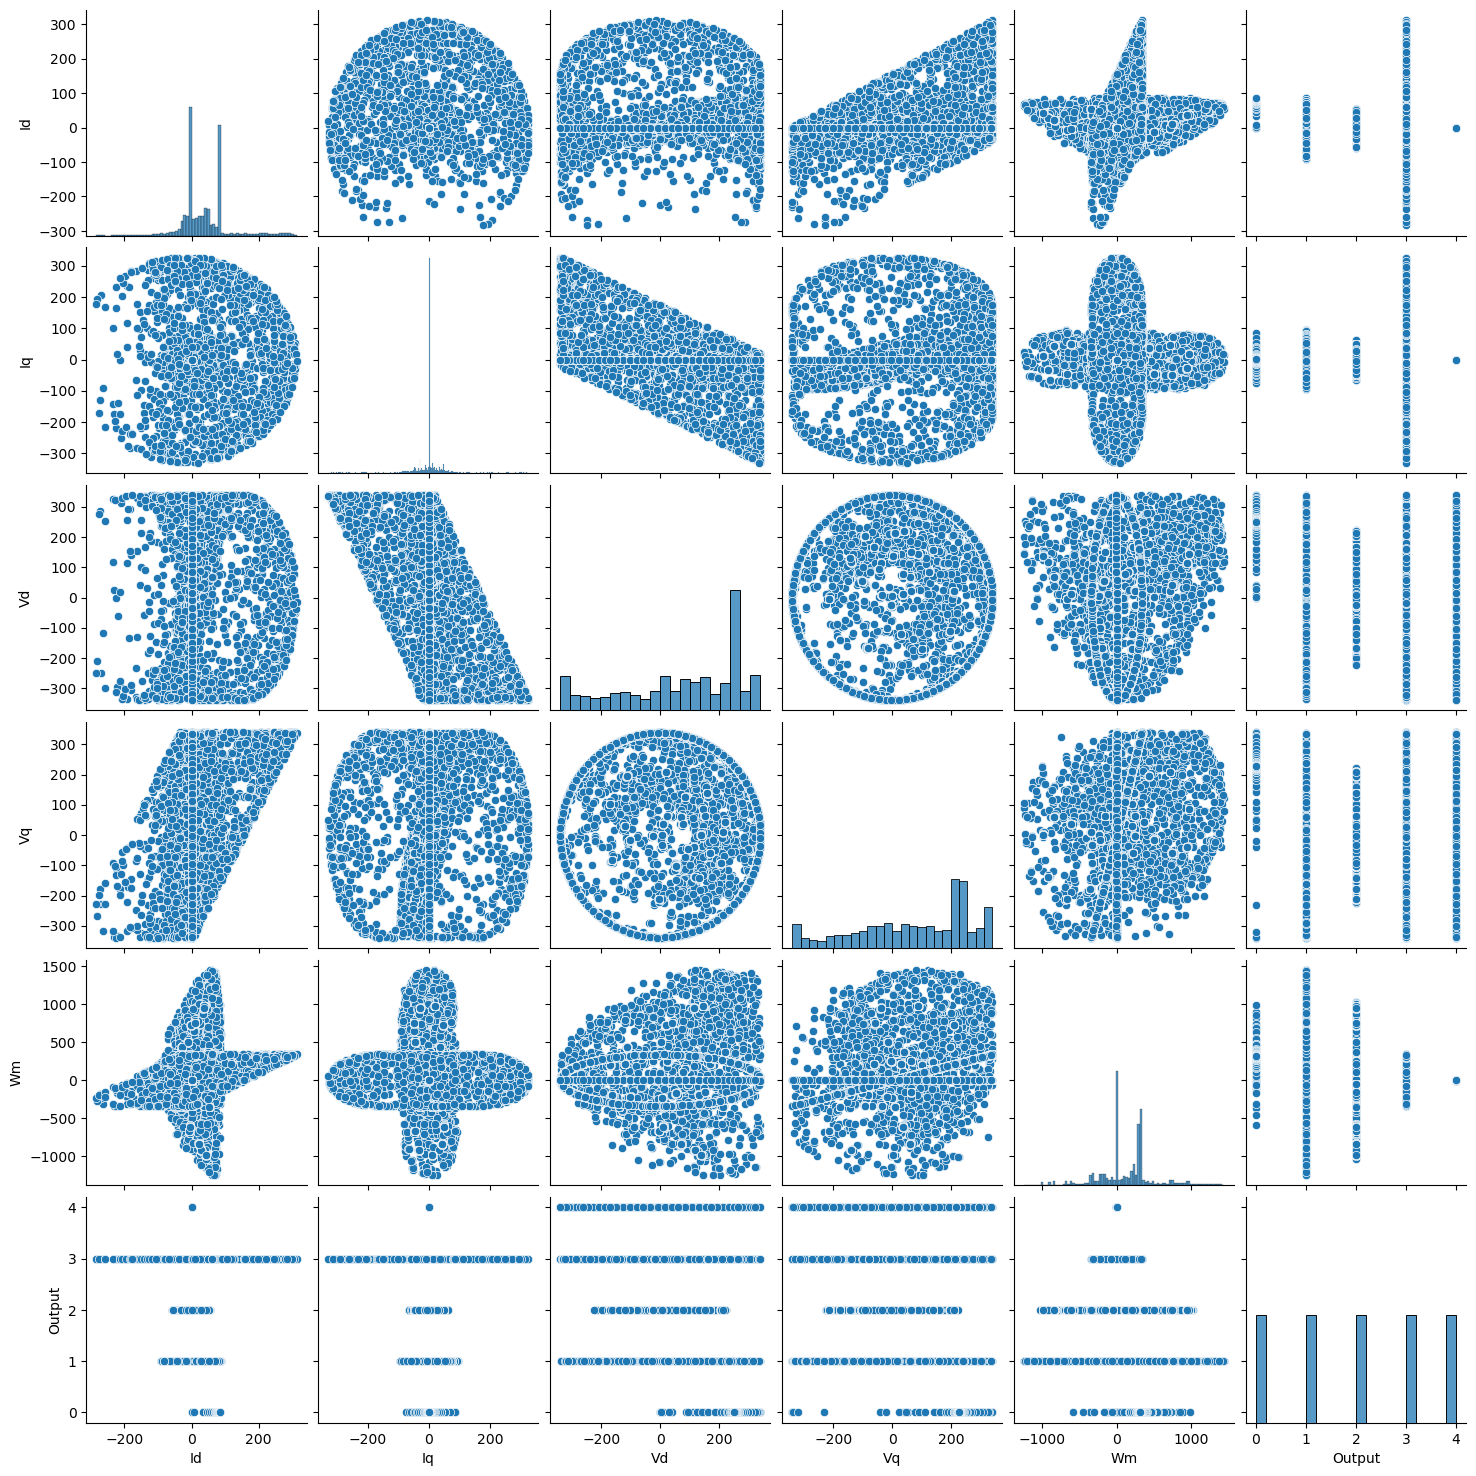

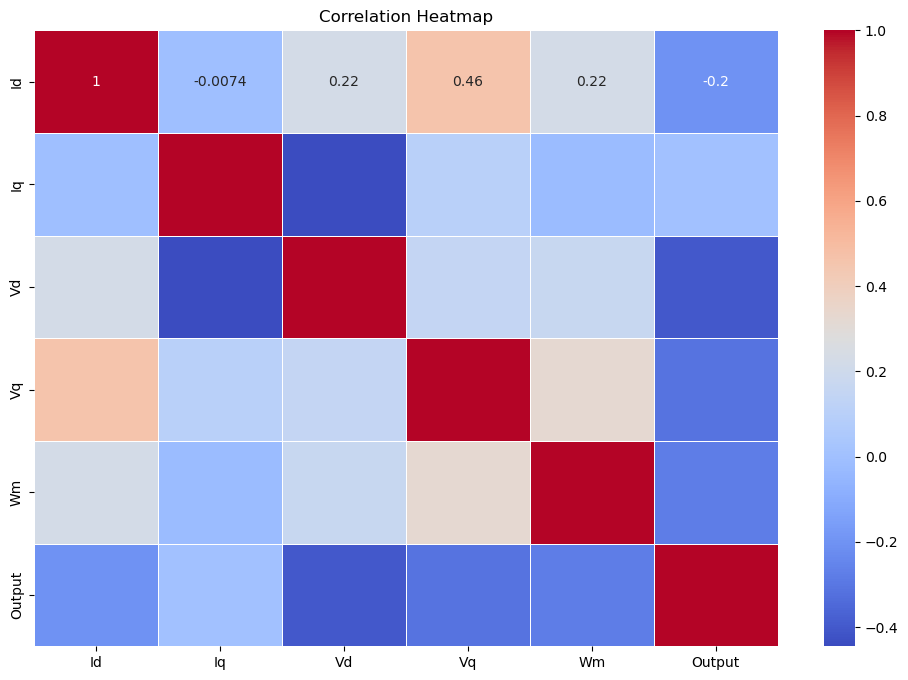

In [6]:

# Scatter plot of Id vs. Iq
#plt.scatter(detect_data['Id'], detect_data['Iq'])
#plt.xlabel('Id')
#plt.ylabel('Iq')
#plt.title('Scatter Plot: Id vs. Iq')
#plt.show()

# Scatter plot of Vd vs. Vq
#plt.scatter(detect_data['Vd'], detect_data['Vq'])
#plt.xlabel('Vd')
#plt.ylabel('Vq')
#plt.title('Scatter Plot: Vd vs. Vq')
#plt.show()

# Boxplot of numerical columns
plt.figure(figsize=(12, 8))
sns.boxplot(data=class_df.select_dtypes(include=['float64', 'int64']))
plt.title('Boxplot of Numerical Columns')
plt.xticks(rotation=90)
plt.show()



# Pairplot for relationships between all numerical columns
sns.pairplot(class_df.select_dtypes(include=['float64', 'int64']))
plt.show()

# Heatmap for correlation matrix
plt.figure(figsize=(12, 8))
corr_matrix = class_df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()




In [7]:
# Extract features and target variable
target_column='Output'
X=class_df.drop(columns=target_column)
y=class_df[target_column]
#X=detect_df.drop(columns=target_column)
#y=detect_df[target_column]


# Split data into training and test sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)

#Further split temporary set into validation and test sets
X_val, X_test, y_val, y_test=train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [8]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled= scaler.transform(X_test)
label_encoder = LabelEncoder()
label_encoder.fit(y_train)


LabelEncoder()

In [9]:
#define the ANN model:
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(len(label_encoder.classes_), activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

#TODO:modify accordingly


In [10]:
#define a callback to monitor training and validation loss:
class LossCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        print(f"Epoch {epoch+1}: Training loss = {logs.get('loss')}, Validation loss = {logs.get('val_loss')}")

loss_callback = LossCallback()


In [11]:

# Train the model
history = model.fit(X_train_scaled, y_train, epochs=35, validation_data=(X_val_scaled, y_val), callbacks=[loss_callback])


Epoch 1/35
188/188 [==============================] - 2s 6ms/step - loss: 0.8180 - accuracy: 0.7503 - val_loss: 0.4338 - val_accuracy: 0.8708
Epoch 2/35
188/188 [==============================] - 1s 3ms/step - loss: 0.2953 - accuracy: 0.9303 - val_loss: 0.2284 - val_accuracy: 0.9534
Epoch 3/35
188/188 [==============================] - 1s 3ms/step - loss: 0.1631 - accuracy: 0.9647 - val_loss: 0.1480 - val_accuracy: 0.9747
Epoch 4/35
188/188 [==============================] - 1s 3ms/step - loss: 0.1045 - accuracy: 0.9800 - val_loss: 0.1031 - val_accuracy: 0.9800
Epoch 5/35
188/188 [==============================] - 1s 3ms/step - loss: 0.0737 - accuracy: 0.9869 - val_loss: 0.0767 - val_accuracy: 0.9814
Epoch 6/35
188/188 [==============================] - 1s 3ms/step - loss: 0.0549 - accuracy: 0.9890 - val_loss: 0.0697 - val_accuracy: 0.9840
Epoch 7/35
188/188 [==============================] - 1s 3ms/step - loss: 0.0437 - accuracy: 0.9928 - val_loss: 0.0576 - val_accuracy: 0.9867
Epoch 

24/24 [==============================] - 0s 2ms/step - loss: 0.0194 - accuracy: 0.9947
Test Loss: 0.019403062760829926
Test Accuracy: 0.9946808218955994
24/24 [==============================] - 0s 2ms/step - loss: 0.0057 - accuracy: 0.9987
Validation Loss: 0.00569172203540802
Validation Accuracy: 0.9986684322357178
24/24 [==============================] - 0s 2ms/step

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       146
           1       1.00      0.98      0.99       167
           2       0.99      1.00      1.00       147
           3       0.99      1.00      1.00       148
           4       0.99      1.00      0.99       144

    accuracy                           0.99       752
   macro avg       0.99      1.00      0.99       752
weighted avg       0.99      0.99      0.99       752



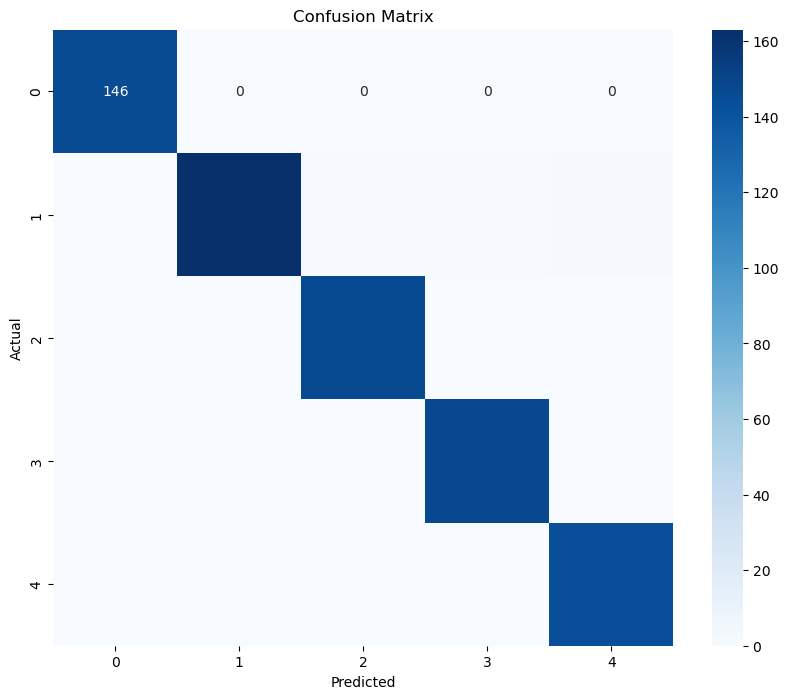

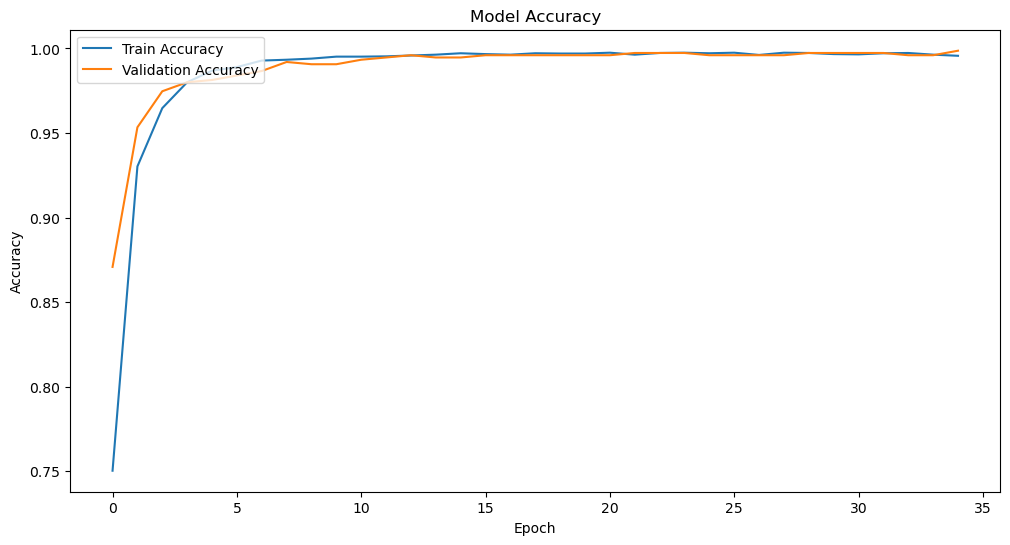

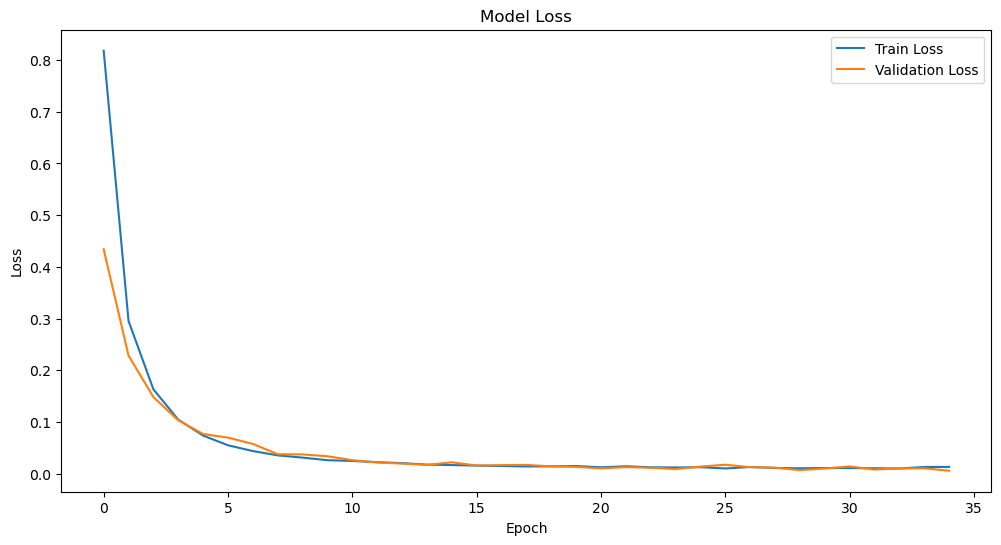

In [12]:
# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

val_loss, val_accuracy = model.evaluate(X_val_scaled, y_val)
print(f"Validation Loss: {val_loss}")
print(f"Validation Accuracy: {val_accuracy}")

# Generate predictions
y_pred_prob = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_prob, axis=1)

# Generate classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Generate confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Plot training & validation accuracy values
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='upper left')
plt.show()

# Plot training & validation loss values
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.show()